<a href="https://colab.research.google.com/github/kiruththigan/Earthquake-Alert-Consolidation/blob/main/dissertation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A Spatio-Temporal Multi-Source  Correlation  Framework  for Earthquake Alert Consolidation and Escalation-Trend Detection

In [1]:
import os
import pandas as pd
import numpy as np

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

import matplotlib.pyplot as plt

In [11]:
import kagglehub

path = kagglehub.dataset_download("kiruththigan/disaster-escalation-and-correlation-index")

for files in os.listdir(path):
    print(files)

Using Colab cache for faster access to the 'disaster-escalation-and-correlation-index' dataset.
manifest.json
correlations.csv
alerts_sample.json
measurements.parquet
consolidated_events.csv
data_dictionary.md
raw_event_records.csv
consolidated_events.parquet
alerts.parquet
raw_event_records.parquet
alerts.csv
measurements.csv
correlations.parquet


In [10]:
# Load Dataset

alerts = pd.read_parquet(os.path.join(path, "alerts.parquet"))
consolidated_events = pd.read_parquet(os.path.join(path, "consolidated_events.parquet"))
raw_events = pd.read_parquet(os.path.join(path, "raw_event_records.parquet"))

print("alerts shape:", alerts.shape)
print("consolidated_events shape:", consolidated_events.shape)
print("raw_event_records shape:", raw_events.shape)


alerts shape: (116365, 21)
consolidated_events shape: (109924, 21)
raw_event_records shape: (350109, 11)


In [ ]:
alerts.head()

,alert_id,source,source_event_id,hazard_type,title,description,alert_level,event_time,lat,lon,...,primary_measurement_type,countries,regions,source_urls,geojson,additional_data,disaster_event_id,normalized_record_id,created_at,updated_at
0,USGS:nc75169346,USGS,nc75169346,EARTHQUAKE,"M 2.0 - 9 km WSW of Esparto, CA","2.04 earthquake 9 km WSW of Esparto, CA",GREEN,2025-04-21 18:03:56.450000+00:00,38.638168,-122.095833,...,magnitude,[],"[{""region_name"": ""Esparto"", ""country_iso3"": nu...","{""event_page"": ""https://earthquake.usgs.gov/ea...",null,"{""cdi"": null, ""mmi"": null, ""code"": ""nc75169346...",deb506a2-837d-427d-abe6-49b1f71dc11f,c1dad23a-3b9d-4d23-85cc-a7c06ae5acd1,2025-04-27 15:23:01.208110,2025-04-27 20:42:48.675453
1,USGS:hv74657637,USGS,hv74657637,EARTHQUAKE,"M 2.0 - 14 km S of Fern Forest, Hawaii","2.02 earthquake 14 km S of Fern Forest, Hawaii",GREEN,2025-04-21 18:18:22.920000+00:00,19.331167,-155.145172,...,magnitude,[],"[{""region_name"": ""Fern Forest"", ""country_iso3""...","{""event_page"": ""https://earthquake.usgs.gov/ea...",null,"{""cdi"": null, ""mmi"": null, ""code"": ""hv74657637...",082dd81d-fe81-40ba-baf6-5397012f9f17,b64bea43-5bfc-42b6-9f80-ab74a52aa70f,2025-04-27 15:23:06.189856,2025-04-27 15:23:06.181484
2,USGS:ak02553vokqu,USGS,ak02553vokqu,EARTHQUAKE,"M 2.3 - 41 km NNW of Valdez, Alaska","2.3 earthquake 41 km NNW of Valdez, Alaska",GREEN,2025-04-21 18:52:49.347000+00:00,61.480200,-146.618600,...,magnitude,[],"[{""region_name"": ""Valdez"", ""country_iso3"": nul...","{""event_page"": ""https://earthquake.usgs.gov/ea...",null,"{""cdi"": null, ""mmi"": null, ""code"": ""ak02553vok...",dce52600-5484-4099-a525-a3716cefe66d,f0e81a28-c01d-494f-bf59-fcdd015810a3,2025-04-27 15:23:08.550616,2025-04-27 15:23:08.542809
3,USGS:nn00896633,USGS,nn00896633,EARTHQUAKE,"M 0.6 - 48 km NE of Beatty, Nevada","0.6 earthquake 48 km NE of Beatty, Nevada",GREEN,2025-04-21 18:56:45.147000+00:00,37.154200,-116.305200,...,magnitude,[],"[{""region_name"": ""Beatty"", ""country_iso3"": nul...","{""event_page"": ""https://earthquake.usgs.gov/ea...",null,"{""cdi"": null, ""mmi"": null, ""code"": ""nn00896633...",c3b3bbca-8487-40ea-b91f-53c53d63c262,7975ceae-a48a-40d0-abb2-44449447c001,2025-04-27 15:23:09.776432,2025-04-27 15:23:09.769148
4,USGS:ci40935519,USGS,ci40935519,EARTHQUAKE,"M 1.1 - 5 km SSE of Julian, CA","1.12 earthquake 5 km SSE of Julian, CA",GREEN,2025-04-21 14:53:45.800000+00:00,33.031833,-116.585333,...,magnitude,[],"[{""region_name"": ""Julian"", ""country_iso3"": nul...","{""event_page"": ""https://earthquake.usgs.gov/ea...",null,"{""cdi"": null, ""mmi"": null, ""code"": ""ci40935519...",52e965cd-19d4-4edf-8d2d-db7284b24e89,ea1bb11d-c301-4029-92ba-9bd4ba066080,2025-04-27 15:23:49.019671,2025-04-27 15:23:49.013316


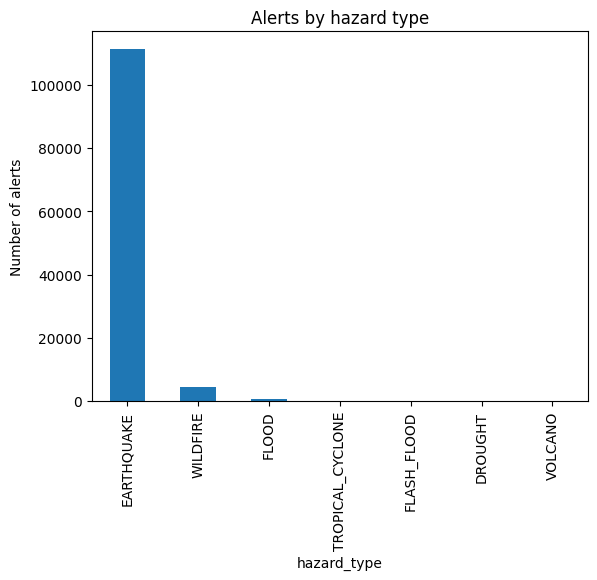

In [ ]:
alerts["hazard_type"].value_counts().plot(kind="bar")
plt.ylabel("Number of alerts")
plt.title("Alerts by hazard type")
plt.show()


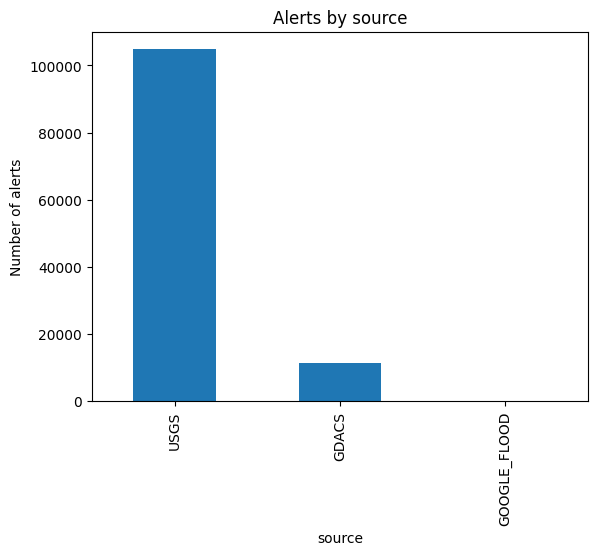

In [ ]:
alerts["source"].value_counts().plot(kind="bar")
plt.ylabel("Number of alerts")
plt.title("Alerts by source")
plt.show()

## Step 5 — Filter to earthquake alerts, clean, and convert time

In [ ]:
# Dataset Cleaning
eq = alerts[alerts["hazard_type"] == "EARTHQUAKE"].copy()
eq = eq[["alert_id", "source", "event_time", "lat", "lon", "severity_raw", "disaster_event_id"]]
eq = eq.dropna(subset=["lat", "lon", "event_time", "severity_raw"])

eq["event_time"] = pd.to_datetime(eq["event_time"])
eq["time_seconds"] = eq["event_time"].astype("int64") // 10**9

n_eq_alerts_used = len(eq)

# Untouched earthquake
eq_base = eq.copy()

print("Number of earthquake alerts we will use:", n_eq_alerts_used)
eq.head()


Number of earthquake alerts we will use: 102044


,alert_id,source,event_time,lat,lon,severity_raw,disaster_event_id,time_seconds
0,USGS:nc75169346,USGS,2025-04-21 18:03:56.450000+00:00,38.638168,-122.095833,2.04,deb506a2-837d-427d-abe6-49b1f71dc11f,1745258
1,USGS:hv74657637,USGS,2025-04-21 18:18:22.920000+00:00,19.331167,-155.145172,2.02,082dd81d-fe81-40ba-baf6-5397012f9f17,1745259
2,USGS:ak02553vokqu,USGS,2025-04-21 18:52:49.347000+00:00,61.480200,-146.618600,2.30,dce52600-5484-4099-a525-a3716cefe66d,1745261
3,USGS:nn00896633,USGS,2025-04-21 18:56:45.147000+00:00,37.154200,-116.305200,0.60,c3b3bbca-8487-40ea-b91f-53c53d63c262,1745261
4,USGS:ci40935519,USGS,2025-04-21 14:53:45.800000+00:00,33.031833,-116.585333,1.12,52e965cd-19d4-4edf-8d2d-db7284b24e89,1745247


## Step 6 — Date range diagnostic

Confirmed in the previous run: earthquake alerts in this dataset only start around April 2025,
even before any filtering — the full multi-hazard dataset goes back to 2022, but earthquake
coverage specifically is shorter (~13 months). Worth stating this plainly as your study's actual
temporal scope.

In [ ]:
all_alerts_time = pd.to_datetime(alerts["event_time"])
print("Full alerts.parquet date range (all hazard types):")
print(all_alerts_time.min(), "to", all_alerts_time.max())
print()

eq_before_dropna = alerts[alerts["hazard_type"] == "EARTHQUAKE"].copy()
eq_before_dropna["event_time"] = pd.to_datetime(eq_before_dropna["event_time"])
print("Earthquake alerts date range BEFORE dropping missing values:")
print(eq_before_dropna["event_time"].min(), "to", eq_before_dropna["event_time"].max())
print("Row count before dropna:", len(eq_before_dropna))
print()

print("Earthquake alerts date range AFTER dropping missing values (what we actually use):")
print(eq["event_time"].min(), "to", eq["event_time"].max())
print("Row count after dropna:", len(eq))


Full alerts.parquet date range (all hazard types):
2022-09-21 00:00:00+00:00 to 2026-05-13 08:42:04.300000+00:00

Earthquake alerts date range BEFORE dropping missing values:
2025-04-17 17:15:33+00:00 to 2026-05-13 08:42:04.300000+00:00
Row count before dropna: 111253

Earthquake alerts date range AFTER dropping missing values (what we actually use):
2025-04-17 17:15:33+00:00 to 2026-04-06 08:52:17.190000+00:00
Row count after dropna: 102044


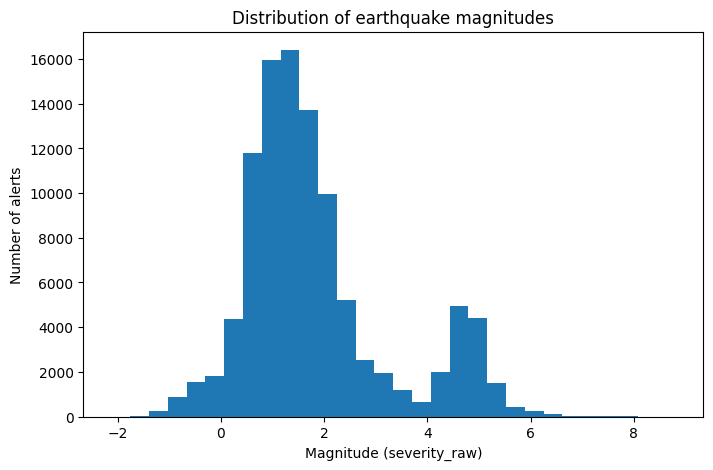

In [ ]:
# Distribution of earthquake magnitudes
plt.figure(figsize=(8, 5))
plt.hist(eq["severity_raw"], bins=30)
plt.xlabel("Magnitude (severity_raw)")
plt.ylabel("Number of alerts")
plt.title("Distribution of earthquake magnitudes")
plt.show()


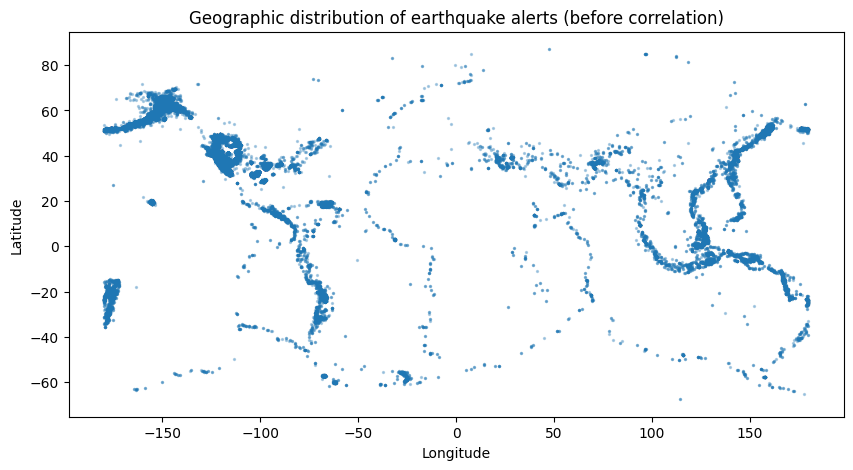

In [ ]:
# Geographic distribution of earthquake alerts
plt.figure(figsize=(10, 5))
plt.scatter(eq["lon"], eq["lat"], s=2, alpha=0.3)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic distribution of earthquake alerts (before correlation)")
plt.show()


In [ ]:
# group by real-world location using Haversine
coords_radians = np.radians(eq_base[["lat", "lon"]])

eps_km = 150
eps_radians = eps_km / 6371  # 6371 km = Earth's radius

spatial_dbscan = DBSCAN(eps=eps_radians, min_samples=2, metric="haversine")
eq["spatial_cluster_id"] = spatial_dbscan.fit_predict(coords_radians)

n_spatial_clusters = len(set(eq["spatial_cluster_id"])) - (1 if -1 in eq["spatial_cluster_id"].values else 0)
n_noise = (eq["spatial_cluster_id"] == -1).sum()

print("Number of location-based groups found:", n_spatial_clusters)
print("Number of alerts with no nearby match (noise):", n_noise)


Number of location-based groups found: 397
Number of alerts with no nearby match (noise): 88


In [ ]:
spatial_only = eq[eq["spatial_cluster_id"] != -1]
spatial_coords_radians = np.radians(spatial_only[["lat", "lon"]])

sil_score = silhouette_score(
    spatial_coords_radians, spatial_only["spatial_cluster_id"],
    metric="haversine",
    # sample_size=5000, random_state=4
)
db_score = davies_bouldin_score(
    spatial_coords_radians, spatial_only["spatial_cluster_id"]
)

# CHI can't use Haversine - sklearn's implementation has no metric option and is fixed
# to Euclidean-space variance, so we use standardized coordinates instead
chi_scaler = StandardScaler()
spatial_coords_scaled = chi_scaler.fit_transform(spatial_only[["lat", "lon"]])
chi_score = calinski_harabasz_score(spatial_coords_scaled, spatial_only["spatial_cluster_id"])

print("Silhouette Score, spatial clustering (higher is better, max 1):", round(sil_score, 3))
print("Davies-Bouldin Index, spatial clustering (lower is better):", round(db_score, 3))
print("Calinski-Harabasz Index, spatial clustering (higher is better, standardized coords):", round(chi_score, 1))


Silhouette Score, spatial clustering (higher is better, max 1): 0.241
Davies-Bouldin Index, spatial clustering (lower is better): 0.931
Calinski-Harabasz Index, spatial clustering (higher is better, standardized coords): 3586.1


In [ ]:
#split location groups by time gap

TIME_GAP_HOURS = 6

def add_time_groups(df, time_gap_hours):
    df_sorted = df.sort_values(["spatial_cluster_id", "event_time"]).copy()
    # Time gap since the previous alert IN THE SAME spatial cluster (NaN at the start of each group)
    time_diff_hours = df_sorted.groupby("spatial_cluster_id")["event_time"].diff().dt.total_seconds() / 3600
    starts_new_group = (time_diff_hours > time_gap_hours) | (time_diff_hours.isna())
    # Cumulative count of "new group" flags, restarting at 0 for each spatial cluster
    df_sorted["time_group"] = starts_new_group.groupby(df_sorted["spatial_cluster_id"]).cumsum()
    return df_sorted

located = eq[eq["spatial_cluster_id"] != -1].copy()
located = add_time_groups(located, TIME_GAP_HOURS)

located["cluster_id"] = (
    located["spatial_cluster_id"].astype(str) + "_" + located["time_group"].astype(str)
)

eq = located

n_final_clusters = eq["cluster_id"].nunique()
print("Number of final space+time matched events:", n_final_clusters)


Number of final space+time matched events: 6131


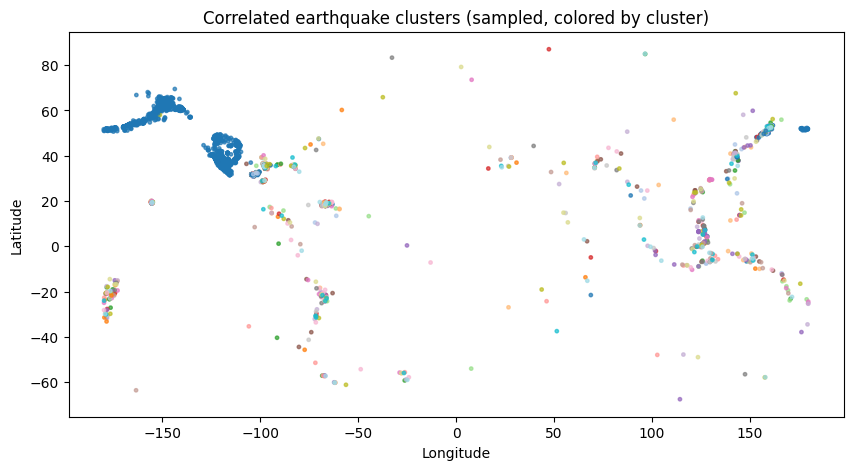

In [ ]:
# Visualize the correlated clusters

sample = eq.sample(n=min(5000, len(eq)), random_state=42)
cluster_numbers = pd.factorize(sample["cluster_id"])[0]

plt.figure(figsize=(10, 5))
plt.scatter(sample["lon"], sample["lat"], c=cluster_numbers, cmap="tab20", s=6, alpha=0.7)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Correlated earthquake clusters (sampled, colored by cluster)")
plt.show()


In [ ]:
# Baseline agreement
def average_agreement(df, cluster_column):
    # Count how many alerts in each (cluster, disaster_event_id) pair
    counts = df.groupby([cluster_column, "disaster_event_id"]).size()
    # For each cluster, the largest count = alerts agreeing with the most common event
    max_counts = counts.groupby(level=0).max()
    cluster_sizes = df.groupby(cluster_column).size()
    agreement_per_cluster = max_counts / cluster_sizes
    return agreement_per_cluster.mean()

location_only_agreement = average_agreement(
    eq[eq["spatial_cluster_id"] != -1], "spatial_cluster_id"
)
combined_agreement = average_agreement(eq, "cluster_id")

print("Agreement using location only:      ", round(location_only_agreement * 100, 1), "%")
print("Agreement using location + time split:", round(combined_agreement * 100, 1), "%")


Agreement using location only:       58.7 %
Agreement using location + time split: 76.8 %


In [ ]:
# Consolidation: fuse each cluster into one alert

source_weights = {
    "USGS": 1.0,
    "GDACS": 0.7
}

eq["weight"] = eq["source"].map(source_weights).fillna(0.5)

def consolidate_cluster(group):
    fused_magnitude = np.average(group["severity_raw"], weights=group["weight"])
    fused_lat = group["lat"].mean()
    fused_lon = group["lon"].mean()
    earliest_time = group["event_time"].min()
    num_sources = group["source"].nunique()
    return pd.Series({
        "fused_magnitude": fused_magnitude,
        "fused_lat": fused_lat,
        "fused_lon": fused_lon,
        "earliest_report_time": earliest_time,
        "num_sources": num_sources
    })

consolidated = eq.groupby("cluster_id").apply(consolidate_cluster, include_groups=False).reset_index()
n_consolidated = len(consolidated)

print("Number of consolidated (fused) earthquake events:", n_consolidated)
consolidated.head()


Number of consolidated (fused) earthquake events: 6131


,cluster_id,fused_magnitude,fused_lat,fused_lon,earliest_report_time,num_sources
0,0_1,1.083714,37.046563,-119.740193,2025-04-21 13:00:43.351000+00:00,1
1,0_2,1.145000,35.313334,-119.018002,2025-04-26 06:19:17.110000+00:00,1
2,0_3,1.171829,37.037197,-119.708606,2025-04-27 21:15:16.140000+00:00,2
3,0_4,1.160761,37.833081,-119.017282,2025-06-19 06:19:20.770000+00:00,2
4,100_1,5.300000,-30.788500,147.360200,2025-05-23 16:36:13+00:00,2


In [ ]:
# Find the correct magnitude field to compare against

measurement_columns = [c for c in consolidated_events.columns if "measurement" in c.lower()]
print("Measurement-related columns found in consolidated_events:")
print(measurement_columns)
consolidated_events[["disaster_event_id"] + measurement_columns].head()


Measurement-related columns found in consolidated_events:
['primary_measurement_value', 'primary_measurement_type', 'primary_measurement_unit']


,disaster_event_id,primary_measurement_value,primary_measurement_type,primary_measurement_unit
0,cd6b6e28-a407-4525-8f5b-c84e80ff2ea7,4.50,magnitude,M
1,2a85d12d-bfb0-4add-a57c-78c7035e4291,2.09,magnitude,M
2,841f0075-dba7-44ae-a029-5de74231f516,3.50,magnitude,M
3,618d12aa-5b91-4e1e-bd98-766df14dd6e9,2.10,magnitude,M
4,35573f3d-bab5-485f-8484-51687d59a15b,0.78,magnitude,M


In [ ]:
# Compare our fused magnitude against DECI's actual magnitude field

MAGNITUDE_COLUMN = "primary_measurement_value"

cluster_to_event = eq.groupby("cluster_id")["disaster_event_id"].agg(lambda x: x.mode()[0])
consolidated["disaster_event_id"] = consolidated["cluster_id"].map(cluster_to_event)

comparison = consolidated.merge(
    consolidated_events[["disaster_event_id", MAGNITUDE_COLUMN]],
    on="disaster_event_id",
    how="left"
)

comparison["magnitude_difference"] = (comparison["fused_magnitude"] - comparison[MAGNITUDE_COLUMN]).abs()
mean_mag_diff = comparison["magnitude_difference"].mean()

print("Average difference between our fused magnitude and DECI's baseline magnitude:", round(mean_mag_diff, 3))
comparison[["cluster_id", "fused_magnitude", MAGNITUDE_COLUMN, "magnitude_difference"]].head(10)


Average difference between our fused magnitude and DECI's baseline magnitude: 0.112


,cluster_id,fused_magnitude,primary_measurement_value,magnitude_difference
0,0_1,1.083714,1.10,0.016286
1,0_2,1.145000,1.12,0.025000
2,0_3,1.171829,4.70,3.528171
3,0_4,1.160761,5.90,4.739239
4,100_1,5.300000,5.30,0.000000
5,101_1,4.300000,4.30,0.000000
6,101_2,5.000000,5.00,0.000000
7,101_3,4.500000,4.50,0.000000
8,101_4,4.800000,4.80,0.000000
9,101_5,4.500000,4.50,0.000000


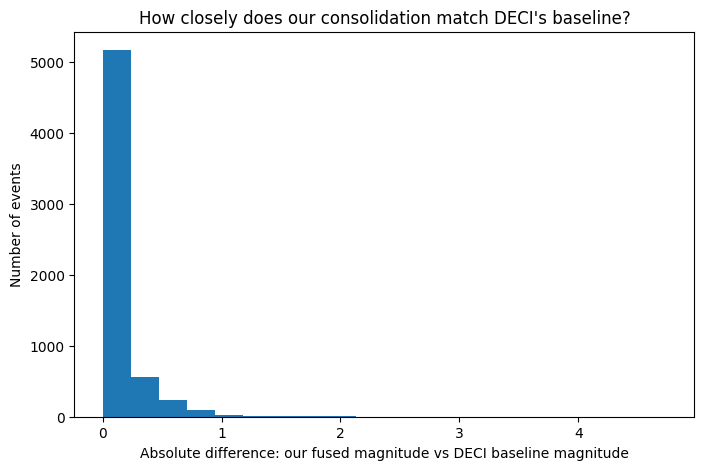

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(comparison["magnitude_difference"].dropna(), bins=20)
plt.xlabel("Absolute difference: our fused magnitude vs DECI baseline magnitude")
plt.ylabel("Number of events")
plt.title("How closely does our consolidation match DECI's baseline?")
plt.show()
#

In [ ]:
# Results summary (default settings: 50 km, 6 hours)

results_summary = pd.DataFrame({
    "Metric": [
        "Earthquake alerts used",
        "Location-based groups found",
        "Unmatched alerts (noise)",
        "Final space+time matched events",
        "Agreement with baseline - location only (%)",
        "Agreement with baseline - location + time (%)",
        "Silhouette Score (spatial clustering, Haversine)",
        "Davies-Bouldin Index (spatial clustering, Haversine)",
        "Calinski-Harabasz Index (spatial clustering, standardized coords)",
        "Consolidated events",
        "Mean |fused magnitude - baseline magnitude|"
    ],
    "Value": [
        n_eq_alerts_used,
        n_spatial_clusters,
        n_noise,
        n_final_clusters,
        round(location_only_agreement * 100, 1),
        round(combined_agreement * 100, 1),
        round(sil_score, 3),
        round(db_score, 3),
        round(chi_score, 1),
        n_consolidated,
        round(mean_mag_diff, 3)
    ]
})

results_summary


,Metric,Value
0,Earthquake alerts used,102044.000
1,Location-based groups found,397.000
2,Unmatched alerts (noise),88.000
3,Final space+time matched events,6131.000
4,Agreement with baseline - location only (%),58.700
5,Agreement with baseline - location + time (%),76.800
6,"Silhouette Score (spatial clustering, Haversine)",0.241
7,"Davies-Bouldin Index (spatial clustering, Have...",0.931
8,"Calinski-Harabasz Index (spatial clustering, s...",3586.100
9,Consolidated events,6131.000


## Parameter finetuning

In [ ]:
def run_correlation_pipeline(eps_km, time_gap_hours):
    # Stage 1: spatial clustering with the given eps_km - built fresh from eq_base every time
    coords_radians_local = np.radians(eq_base[["lat", "lon"]])
    eps_radians = eps_km / 6371
    dbscan = DBSCAN(eps=eps_radians, min_samples=2, metric="haversine")
    spatial_labels = dbscan.fit_predict(coords_radians_local)

    working = eq_base[["event_time", "lat", "lon", "disaster_event_id"]].copy()
    working["spatial_cluster_id"] = spatial_labels

    n_spatial = len(set(spatial_labels)) - (1 if -1 in spatial_labels else 0)
    n_noise_local = int((spatial_labels == -1).sum())

    # Stage 2: split by the given time gap (fast, vectorized version from Step 10)
    located_local = working[working["spatial_cluster_id"] != -1].copy()
    located_local = add_time_groups(located_local, time_gap_hours)
    located_local["cluster_id"] = (
        located_local["spatial_cluster_id"].astype(str) + "_" + located_local["time_group"].astype(str)
    )

    n_final = located_local["cluster_id"].nunique()

    # Agreement with DECI's baseline grouping (fast, vectorized version from Step 12)
    location_only_agree = average_agreement(
        working[working["spatial_cluster_id"] != -1], "spatial_cluster_id"
    )
    combined_agree = average_agreement(located_local, "cluster_id")

    # Cluster shape (spatial stage only, Haversine)
    # sample_size keeps this fast even with ~100,000 points - see Step 9's explanation
    spatial_only_local = working[working["spatial_cluster_id"] != -1]
    spatial_coords_local = np.radians(spatial_only_local[["lat", "lon"]])
    sil = silhouette_score(
        spatial_coords_local, spatial_only_local["spatial_cluster_id"],
        metric="haversine",
        #sample_size=5000, random_state=42
    )
    db = davies_bouldin_score(spatial_coords_local, spatial_only_local["spatial_cluster_id"])

    # CHI - standardized coordinates, not Haversine (see main evaluation cell's explanation)
    chi_scaler_local = StandardScaler()
    spatial_coords_scaled_local = chi_scaler_local.fit_transform(spatial_only_local[["lat", "lon"]])
    chi = calinski_harabasz_score(spatial_coords_scaled_local, spatial_only_local["spatial_cluster_id"])

    return {
        "eps_km": eps_km,
        "time_gap_hours": time_gap_hours,
        "spatial_clusters": n_spatial,
        "noise": n_noise_local,
        "final_clusters": n_final,
        "agreement_location_only_%": round(location_only_agree * 100, 1),
        "agreement_combined_%": round(combined_agree * 100, 1),
        "silhouette": round(sil, 3),
        "davies_bouldin": round(db, 3),
        "calinski_harabasz": round(chi, 1)
    }


In [ ]:
import time

SPACE_VALUES = [50, 100, 150]   # km
TIME_VALUES = [10, 30, 60]      # minutes

sensitivity_results = []
for eps_km_test, time_gap_minutes_test in zip(SPACE_VALUES, TIME_VALUES):
    time_gap_hours_test = time_gap_minutes_test / 60  # convert minutes to hours

    start_time = time.time()
    result = run_correlation_pipeline(eps_km_test, time_gap_hours_test)
    elapsed_seconds = round(time.time() - start_time, 1)

    result["time_gap_minutes"] = time_gap_minutes_test
    sensitivity_results.append(result)

    print(
        f"eps_km={eps_km_test}, time_gap={time_gap_minutes_test}min: "
        f"done in {elapsed_seconds}s, {result['final_clusters']} final clusters"
    )

sensitivity_df = pd.DataFrame(sensitivity_results)
sensitivity_df


eps_km=50, time_gap=10min: done in 737.9s, 55352 final clusters
eps_km=100, time_gap=30min: done in 743.7s, 26527 final clusters
eps_km=150, time_gap=60min: done in 746.6s, 16113 final clusters


,eps_km,time_gap_hours,spatial_clusters,noise,final_clusters,agreement_location_only_%,agreement_combined_%,silhouette,davies_bouldin,calinski_harabasz,time_gap_minutes
0,50,0.166667,1336,482,55352,65.4,79.6,-0.119,3.555,1372.1,10
1,100,0.500000,632,183,26527,61.1,70.7,0.206,2.201,2448.8,30
2,150,1.000000,397,88,16113,58.7,74.3,0.241,0.931,3586.1,60


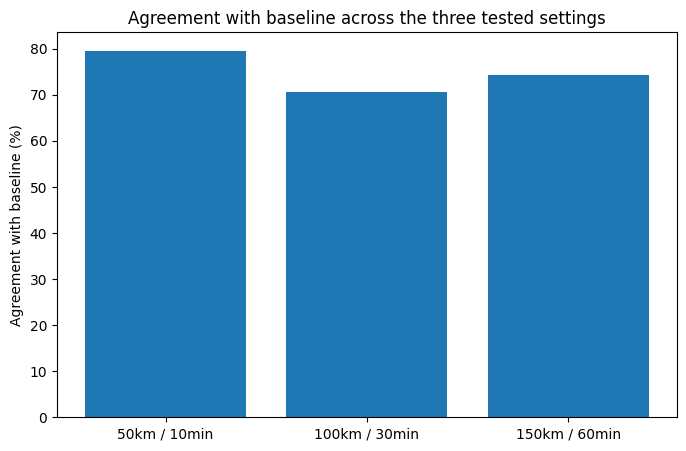

In [ ]:
# A bar chart showing how agreement with DECI's baseline changes across the strict, medium, and loose settings

setting_labels = [f"{eps}km / {mins}min" for eps, mins in zip(SPACE_VALUES, TIME_VALUES)]

plt.figure(figsize=(8, 5))
plt.bar(setting_labels, sensitivity_df["agreement_combined_%"])
plt.ylabel("Agreement with baseline (%)")
plt.title("Agreement with baseline across the three tested settings")
plt.show()

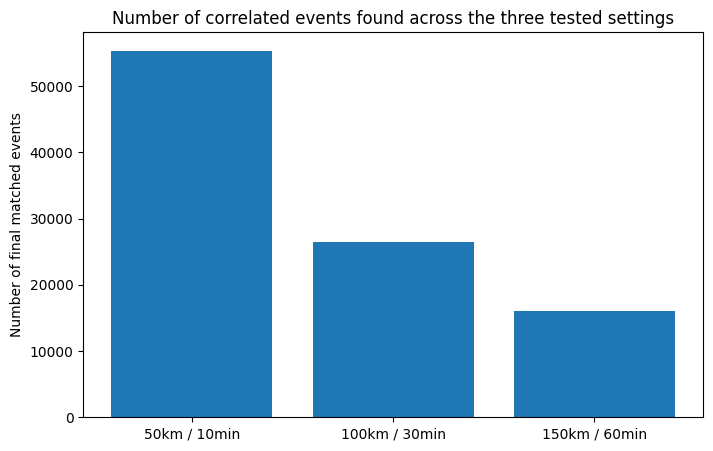

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(setting_labels, sensitivity_df["final_clusters"])
plt.ylabel("Number of final matched events")
plt.title("Number of correlated events found across the three tested settings")
plt.show()


# Escalation-Trend Detection

## Explore raw_event_records.parquet

In [ ]:
raw_events.head()

,raw_record_id,source,source_event_id,event_hash,timestamp,source_reported_at,processing_status,normalized_record_id,disaster_event_id,previous_record_id,raw_data
0,d88393c6-ef19-47f5-8a4c-071ad6366f5f,USGS,av93713063,4534fdb4e58252f51775bdae22063666,2025-08-19 10:54:56.503492+00:00,2025-08-12 07:00:52.580000+00:00,LINKED,02614266-4da4-4e54-b9a4-bb82642c3354,None,None,"{""id"": ""av93713063"", ""type"": ""Feature"", ""geome..."
1,5ab42581-e994-496a-b01a-9f9349ee0e3a,USGS,nc75169346,8af4e1d1c362e3e0d7b946b5cc58b8b7,2025-04-27 15:23:00.404875+00:00,2025-04-21 18:03:56.450000+00:00,SUPERSEDED,c1dad23a-3b9d-4d23-85cc-a7c06ae5acd1,None,None,"{""id"": ""nc75169346"", ""type"": ""Feature"", ""geome..."
2,d64a76f4-1f70-4f38-8e4c-d48a19892f15,USGS,ci40935839,56caa4434fcf25ae8a53445ccdc684ed,2025-04-27 19:53:41.049359+00:00,2025-04-21 18:06:22.050000+00:00,LINKED,2dffb57d-3045-4c39-9190-ebe83a811544,None,None,"{""id"": ""ci40935839"", ""type"": ""Feature"", ""geome..."
3,5ad6f794-b852-4bbf-85ce-f0b9ca292a8c,USGS,ak02553xz3ho,f477ac276698be3948b4259b45e48ae1,2025-04-27 20:47:44.393380+00:00,2025-04-21 22:37:50.208000+00:00,LINKED,76e1cba5-ed51-425c-a655-41aeba318a10,None,None,"{""id"": ""ak02553xz3ho"", ""type"": ""Feature"", ""geo..."
4,dd241e59-1c1f-4d2c-9289-f8728fac9184,USGS,nc75172841,1ffa640b21581f9013cab5552995ad90,2025-04-27 21:52:44.415520+00:00,2025-04-27 21:38:10.050000+00:00,LINKED,a60849ca-4037-472d-8f8e-df8b026a1d69,None,None,"{""id"": ""nc75172841"", ""type"": ""Feature"", ""geome..."


In [ ]:
revisions_per_event = raw_events.groupby("disaster_event_id").size()

print("Revisions per event - summary statistics:")
print(revisions_per_event.describe())
print()
print("Number of events with more than 1 revision (a real trajectory to study):", (revisions_per_event > 1).sum())
print("Number of events with only 1 revision (no trend possible):", (revisions_per_event == 1).sum())


Revisions per event - summary statistics:
count    27055.000000
mean         3.074219
std         10.643367
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max        851.000000
dtype: float64

Number of events with more than 1 revision (a real trajectory to study): 13584
Number of events with only 1 revision (no trend possible): 13471


In [ ]:
# Bring in severity and time for each revision

eq_with_ids = alerts[alerts["hazard_type"] == "EARTHQUAKE"][
    ["normalized_record_id", "severity_raw", "event_time", "lat", "lon", "disaster_event_id"]
].dropna(subset=["severity_raw", "event_time"]).copy()

eq_with_ids["event_time"] = pd.to_datetime(eq_with_ids["event_time"])

print("Earthquake alerts with an id we can join on:", len(eq_with_ids))


Earthquake alerts with an id we can join on: 102044


In [ ]:
escalation_data = raw_events.merge(
    eq_with_ids[["normalized_record_id", "severity_raw", "event_time", "lat", "lon"]],
    on="normalized_record_id",
    how="inner"  # only keep raw records that successfully match an earthquake alert
)

print("Raw event records successfully matched to an earthquake alert:", len(escalation_data))
escalation_data.head()


Raw event records successfully matched to an earthquake alert: 205390


,raw_record_id,source,source_event_id,event_hash,timestamp,source_reported_at,processing_status,normalized_record_id,disaster_event_id,previous_record_id,raw_data,severity_raw,event_time,lat,lon
0,d88393c6-ef19-47f5-8a4c-071ad6366f5f,USGS,av93713063,4534fdb4e58252f51775bdae22063666,2025-08-19 10:54:56.503492+00:00,2025-08-12 07:00:52.580000+00:00,LINKED,02614266-4da4-4e54-b9a4-bb82642c3354,None,None,"{""id"": ""av93713063"", ""type"": ""Feature"", ""geome...",-0.15,2025-08-12 07:00:52.580000+00:00,61.273167,-152.379000
1,5ab42581-e994-496a-b01a-9f9349ee0e3a,USGS,nc75169346,8af4e1d1c362e3e0d7b946b5cc58b8b7,2025-04-27 15:23:00.404875+00:00,2025-04-21 18:03:56.450000+00:00,SUPERSEDED,c1dad23a-3b9d-4d23-85cc-a7c06ae5acd1,None,None,"{""id"": ""nc75169346"", ""type"": ""Feature"", ""geome...",2.04,2025-04-21 18:03:56.450000+00:00,38.638168,-122.095833
2,d64a76f4-1f70-4f38-8e4c-d48a19892f15,USGS,ci40935839,56caa4434fcf25ae8a53445ccdc684ed,2025-04-27 19:53:41.049359+00:00,2025-04-21 18:06:22.050000+00:00,LINKED,2dffb57d-3045-4c39-9190-ebe83a811544,None,None,"{""id"": ""ci40935839"", ""type"": ""Feature"", ""geome...",1.03,2025-04-21 18:06:22.050000+00:00,35.951333,-117.681167
3,5ad6f794-b852-4bbf-85ce-f0b9ca292a8c,USGS,ak02553xz3ho,f477ac276698be3948b4259b45e48ae1,2025-04-27 20:47:44.393380+00:00,2025-04-21 22:37:50.208000+00:00,LINKED,76e1cba5-ed51-425c-a655-41aeba318a10,None,None,"{""id"": ""ak02553xz3ho"", ""type"": ""Feature"", ""geo...",1.60,2025-04-21 22:37:50.208000+00:00,60.240300,-139.662000
4,dd241e59-1c1f-4d2c-9289-f8728fac9184,USGS,nc75172841,1ffa640b21581f9013cab5552995ad90,2025-04-27 21:52:44.415520+00:00,2025-04-27 21:38:10.050000+00:00,LINKED,a60849ca-4037-472d-8f8e-df8b026a1d69,None,None,"{""id"": ""nc75172841"", ""type"": ""Feature"", ""geome...",1.03,2025-04-27 21:38:10.050000+00:00,38.792835,-122.727501


In [ ]:
# Check how many events actually have a usable trajectory

eq_revisions_per_event = escalation_data.groupby("disaster_event_id").size()

print("Earthquake events with more than 1 revision:", (eq_revisions_per_event > 1).sum())
print("Earthquake events with only 1 revision:", (eq_revisions_per_event == 1).sum())
print()
print("Revisions per earthquake event - summary statistics:")
print(eq_revisions_per_event.describe())


Earthquake events with more than 1 revision: 8635
Earthquake events with only 1 revision: 8135

Revisions per earthquake event - summary statistics:
count    16770.000000
mean         2.157185
std          4.795226
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max        360.000000
dtype: float64


In [ ]:
import json

print("Example raw_data payload #1:")
print(escalation_data["raw_data"].iloc[0])
print()
print("Example raw_data payload #2:")
print(escalation_data["raw_data"].iloc[5])
print()
print("Example raw_data payload #3 (from an event we know has multiple revisions):")
example_event_id = escalation_data.groupby("disaster_event_id").size().idxmax()
example_rows = escalation_data[escalation_data["disaster_event_id"] == example_event_id].sort_values("timestamp")
print("Event with the most revisions:", example_event_id, "-", len(example_rows), "revisions")
print(example_rows["raw_data"].iloc[0])


Example raw_data payload #1:
{"id": "av93713063", "type": "Feature", "geometry": {"type": "Point", "coordinates": [-152.379, 61.2731666666667, 3.33]}, "properties": {"tz": null, "cdi": null, "gap": 107, "ids": ",av93713063,", "mag": -0.15, "mmi": null, "net": "av", "nst": 12, "rms": 0.32, "sig": 0, "url": "https://earthquake.usgs.gov/earthquakes/eventpage/av93713063", "code": "93713063", "dmin": 0.01449, "felt": null, "time": 1754982052580, "type": "earthquake", "alert": null, "place": "70 km WNW of Tyonek, Alaska", "title": "M -0.2 - 70 km WNW of Tyonek, Alaska", "types": ",origin,phase-data,", "detail": "https://earthquake.usgs.gov/earthquakes/feed/v1.0/detail/av93713063.geojson", "status": "reviewed", "magType": "ml", "sources": ",av,", "tsunami": 0, "updated": 1755042627760}}

Example raw_data payload #2:
{"id": "hv74657637", "type": "Feature", "geometry": {"type": "Point", "coordinates": [-155.145172119141, 19.3311672210693, 3.24000000953674]}, "properties": {"tz": null, "cdi": nu

In [ ]:
# Extract the real magnitude from each revision's raw payload

def extract_magnitude(raw_json_text):
    try:
        parsed = json.loads(raw_json_text)
        return parsed.get("properties", {}).get("mag")
    except (json.JSONDecodeError, TypeError, AttributeError):
        return None

escalation_data["revision_magnitude"] = escalation_data["raw_data"].apply(extract_magnitude)

print("Successfully extracted a magnitude:", escalation_data["revision_magnitude"].notna().sum())
print("Failed to extract (missing/different format):", escalation_data["revision_magnitude"].isna().sum())
print()
print("Extraction success rate by source (%):")
print((escalation_data.groupby("source")["revision_magnitude"].apply(lambda s: s.notna().mean() * 100)).round(1))


Successfully extracted a magnitude: 193074
Failed to extract (missing/different format): 12316

Extraction success rate by source (%):
source
GDACS      0.0
USGS     100.0
Name: revision_magnitude, dtype: float64


In [ ]:
# Rebuild the trajectory using the real, evolving values

trajectories = escalation_data.dropna(subset=["revision_magnitude"]).copy()
trajectories = trajectories.sort_values(["disaster_event_id", "timestamp"])

revision_counts = trajectories.groupby("disaster_event_id").size()
multi_revision_events = revision_counts[revision_counts > 1].index
trajectories = trajectories[trajectories["disaster_event_id"].isin(multi_revision_events)]

print("Events with a usable multi-point trajectory:", trajectories["disaster_event_id"].nunique())
print("Total revision rows in these trajectories:", len(trajectories))


Events with a usable multi-point trajectory: 8297
Total revision rows in these trajectories: 26287


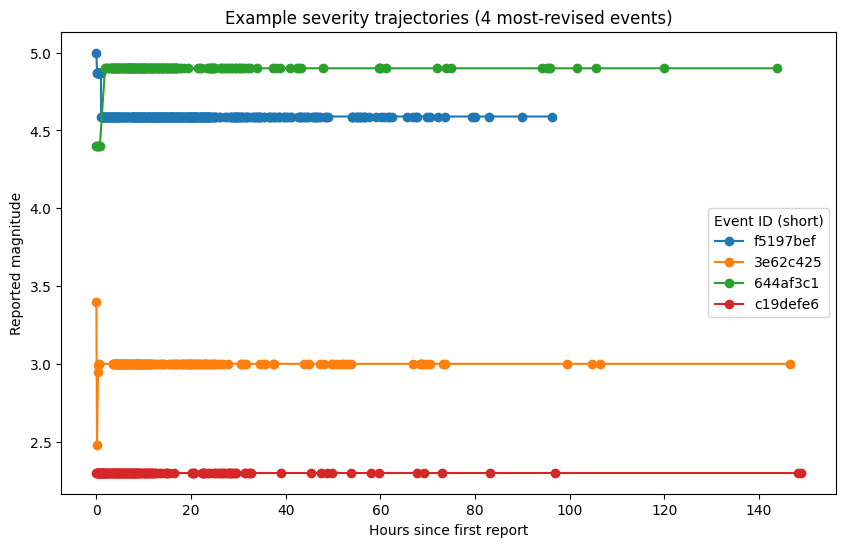

In [ ]:
# Visualize a few real trajectories

example_event_ids = (
    trajectories.groupby("disaster_event_id").size().sort_values(ascending=False).head(4).index
)

plt.figure(figsize=(10, 6))
for event_id in example_event_ids:
    one_event = trajectories[trajectories["disaster_event_id"] == event_id].sort_values("timestamp")
    hours_since_first = (one_event["timestamp"] - one_event["timestamp"].iloc[0]).dt.total_seconds() / 3600
    plt.plot(hours_since_first, one_event["revision_magnitude"], marker="o", label=event_id[:8])

plt.xlabel("Hours since first report")
plt.ylabel("Reported magnitude")
plt.title("Example severity trajectories (4 most-revised events)")
plt.legend(title="Event ID (short)")
plt.show()


In [ ]:
# Detect escalation trends

def compute_trend(group):
    group = group.sort_values("timestamp")
    hours_since_first = (group["timestamp"] - group["timestamp"].iloc[0]).dt.total_seconds() / 3600
    first_magnitude = group["revision_magnitude"].iloc[0]
    last_magnitude = group["revision_magnitude"].iloc[-1]
    max_magnitude = group["revision_magnitude"].max()
    magnitude_change = last_magnitude - first_magnitude

    if hours_since_first.nunique() > 1:
        slope_per_hour = np.polyfit(hours_since_first, group["revision_magnitude"], 1)[0]
    else:
        slope_per_hour = np.nan

    return pd.Series({
        "num_revisions": len(group),
        "first_magnitude": first_magnitude,
        "last_magnitude": last_magnitude,
        "max_magnitude": max_magnitude,
        "magnitude_change": magnitude_change,
        "slope_per_hour": slope_per_hour
    })

event_trends = trajectories.groupby("disaster_event_id").apply(compute_trend, include_groups=False)

ESCALATION_THRESHOLD = 0.05  # magnitude increase per hour, on average
event_trends["escalating"] = event_trends["slope_per_hour"] > ESCALATION_THRESHOLD

print("Events showing an escalating trend:", event_trends["escalating"].sum())
print("Events showing a stable/declining trend:", (~event_trends["escalating"]).sum())
event_trends.sort_values("slope_per_hour", ascending=False).head(10)


Events showing an escalating trend: 405
Events showing a stable/declining trend: 7892


,num_revisions,first_magnitude,last_magnitude,max_magnitude,magnitude_change,slope_per_hour,escalating
disaster_event_id,,,,,,,
0f14d175-7f02-4cc1-a7ec-c00da16393ab,2.0,1.0,1.3,1.3,0.3,658.008975,True
69c29c47-335a-4ef1-8b73-bc5cef529f20,2.0,0.6,0.8,0.8,0.2,114.300573,True
d96001ad-286f-49c4-9815-000969c79c59,2.0,1.1,1.4,1.4,0.3,9.229967,True
cb951065-b984-46eb-bab3-3cbd585066f9,2.0,1.2,1.8,1.8,0.6,8.994120,True
061490e0-eef8-496f-b029-c7181d590e7f,2.0,1.5,2.1,2.1,0.6,8.983974,True
2043ad66-8594-424c-9859-9d723ab029a1,3.0,2.0,3.0,3.0,1.0,7.500202,True
1b6d15ea-b73d-4115-b117-0891af5f66c3,2.0,1.7,1.9,1.9,0.2,6.029289,True
5646a06a-c11b-4571-9cc6-ea516b00982d,2.0,1.4,1.9,1.9,0.5,4.998007,True
e48f0ef1-4da4-4910-b179-1f0e52e51b14,2.0,1.4,1.9,1.9,0.5,4.970834,True


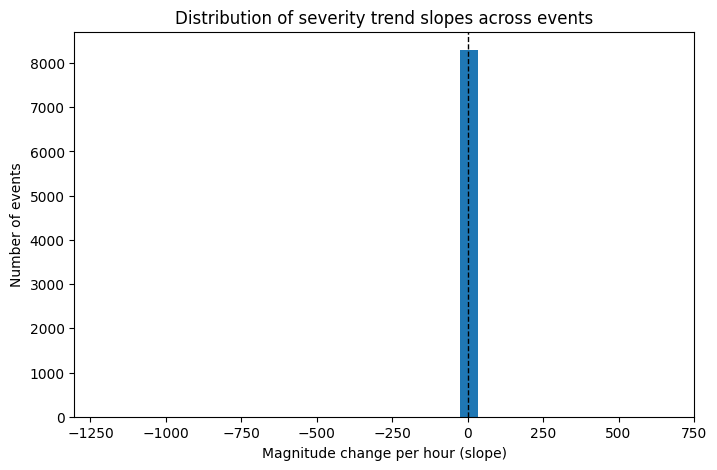

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(event_trends["slope_per_hour"].dropna(), bins=30)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Magnitude change per hour (slope)")
plt.ylabel("Number of events")
plt.title("Distribution of severity trend slopes across events")
plt.show()


In [ ]:
n_trajectory_events = trajectories["disaster_event_id"].nunique()
n_trajectory_revisions = len(trajectories)
n_escalating = int(event_trends["escalating"].sum())
n_stable = int((~event_trends["escalating"]).sum())
escalation_rate_pct = round(n_escalating / len(event_trends) * 100, 1)
avg_change_escalating = round(event_trends.loc[event_trends["escalating"], "magnitude_change"].mean(), 3)
avg_slope_escalating = round(event_trends.loc[event_trends["escalating"], "slope_per_hour"].mean(), 3)

rq4_results_summary = pd.DataFrame({
    "Metric": [
        "Earthquake events with usable trajectory (USGS only)",
        "Total revision rows analysed",
        "Escalation threshold used (magnitude/hour)",
        "Events flagged as escalating",
        "Events stable/declining",
        "Escalation rate (%)",
        "Average magnitude change, escalating events",
        "Average slope, escalating events (magnitude/hour)"
    ],
    "Value": [
        n_trajectory_events,
        n_trajectory_revisions,
        ESCALATION_THRESHOLD,
        n_escalating,
        n_stable,
        escalation_rate_pct,
        avg_change_escalating,
        avg_slope_escalating
    ]
})

rq4_results_summary


,Metric,Value
0,Earthquake events with usable trajectory (USGS...,8297.000
1,Total revision rows analysed,26287.000
2,Escalation threshold used (magnitude/hour),0.050
3,Events flagged as escalating,405.000
4,Events stable/declining,7892.000
5,Escalation rate (%),4.900
6,"Average magnitude change, escalating events",0.307
7,"Average slope, escalating events (magnitude/hour)",2.388


In [ ]:
# results summary: clustering, consolidation & escalation

master_results_summary = pd.DataFrame({
    "Component": [
        "Clustering (Correlation)", "Clustering (Correlation)", "Clustering (Correlation)",
        "Clustering (Correlation)", "Clustering (Correlation)", "Clustering (Correlation)",
        "Clustering (Correlation)", "Clustering (Correlation)", "Clustering (Correlation)",
        "Consolidation", "Consolidation",
        "Escalation", "Escalation", "Escalation", "Escalation", "Escalation", "Escalation"
    ],
    "Metric": [
        "Earthquake alerts used",
        "Location-based groups found",
        "Unmatched alerts (noise)",
        "Final space+time matched events",
        "Agreement with baseline - location only (%)",
        "Agreement with baseline - location + time (%)",
        "Silhouette Score (spatial clustering, Haversine, sampled)",
        "Davies-Bouldin Index (spatial clustering, Haversine)",
        "Calinski-Harabasz Index (spatial clustering, standardized coords)",
        "Consolidated events",
        "Mean |fused magnitude - baseline magnitude|",
        "Earthquake events with usable trajectory (USGS only)",
        "Escalation threshold used (magnitude/hour)",
        "Events flagged as escalating",
        "Events stable/declining",
        "Escalation rate (%)",
        "Average slope, escalating events (magnitude/hour)"
    ],
    "Value": [
        n_eq_alerts_used,
        n_spatial_clusters,
        n_noise,
        n_final_clusters,
        round(location_only_agreement * 100, 1),
        round(combined_agreement * 100, 1),
        round(sil_score, 3),
        round(db_score, 3),
        round(chi_score, 1),
        n_consolidated,
        round(mean_mag_diff, 3),
        n_trajectory_events,
        ESCALATION_THRESHOLD,
        n_escalating,
        n_stable,
        escalation_rate_pct,
        avg_slope_escalating
    ]
})

master_results_summary


,Component,Metric,Value
0,Clustering (Correlation),Earthquake alerts used,102044.000
1,Clustering (Correlation),Location-based groups found,397.000
2,Clustering (Correlation),Unmatched alerts (noise),88.000
3,Clustering (Correlation),Final space+time matched events,6131.000
4,Clustering (Correlation),Agreement with baseline - location only (%),58.700
5,Clustering (Correlation),Agreement with baseline - location + time (%),76.800
6,Clustering (Correlation),"Silhouette Score (spatial clustering, Haversin...",0.241
7,Clustering (Correlation),"Davies-Bouldin Index (spatial clustering, Have...",0.931
8,Clustering (Correlation),"Calinski-Harabasz Index (spatial clustering, s...",3586.100
9,Consolidation,Consolidated events,6131.000
